# Notebook 2 — Modèle Bayésien Hiérarchique

**Groupe 02** — Bayesian Sports Analytics · Premier League  
Cian Higgins · Jules Dantin · Hugo Ferré

---

## Spécification du modèle

Nous implémentons le modèle de **Baio & Blangiardo (2010)** :

$$g_{home} \sim \text{Poisson}(\theta_{home}), \quad g_{away} \sim \text{Poisson}(\theta_{away})$$

$$\log(\theta_{home}) = \mu + \delta + \alpha_{h} - \beta_{a}$$
$$\log(\theta_{away}) = \mu \phantom{+ \delta} + \alpha_{a} - \beta_{h}$$

Où :
- $\mu$ : intercepte (buts de base)
- $\delta$ : avantage à domicile
- $\alpha_k$ : force d'attaque de l'équipe $k$
- $\beta_k$ : force défensive de l'équipe $k$

Priors hiérarchiques :
$$\alpha_k \sim \mathcal{N}(\mu_\alpha, \sigma_\alpha), \quad \beta_k \sim \mathcal{N}(\mu_\beta, \sigma_\beta)$$

In [5]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import arviz as az
import pymc as pm
import warnings
warnings.filterwarnings('ignore')

from src.data.fetch_data import fetch_all_seasons, prepare_dataset, train_test_split_by_matchweek
from src.models.bayesian_model import build_model, sample_model, predict_all_matches, team_strengths
from src.analysis.predictions import evaluate_predictions, calibration_data, confusion_matrix_results

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

PyMC version: 5.28.2
ArviZ version: 0.23.4


## 1. Données

In [6]:
raw = fetch_all_seasons(['2022-23', '2023-24', '2024-25'])
df, teams, team_to_idx = prepare_dataset(raw)
train, test = train_test_split_by_matchweek(df, test_matchweeks=5)

n_teams = len(teams)
print(f'Équipes : {n_teams}')
print(f'Matchs train : {len(train)}')
print(f'Matchs test  : {len(test)}')
print(f'\nÉquipes : {teams}')

Fetching season 2022-23...
Fetching season 2023-24...
Fetching season 2024-25...
Équipes : 24
Matchs train : 1120
Matchs test  : 20

Équipes : ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Sheffield United', 'Southampton', 'Tottenham', 'West Ham', 'Wolves']


## 2. Construction et sampling du modèle

In [7]:
model = build_model(train, n_teams)
print(model.basic_RVs)

[mu_att, mu_def, sigma_att, sigma_def, attack_raw, defense, home_adv, intercept, goals_home, goals_away]


In [8]:
# Visualiser le graphe du modèle (nécessite graphviz : pip install graphviz)
try:
    pm.model_to_graphviz(model)
except ImportError:
    print('graphviz non installé — cellule ignorée.')
    print('Variables du modèle :', [v.name for v in model.basic_RVs])

graphviz non installé — cellule ignorée.
Variables du modèle : ['mu_att', 'mu_def', 'sigma_att', 'sigma_def', 'attack_raw', 'defense', 'home_adv', 'intercept', 'goals_home', 'goals_away']


In [9]:
%%time
# NUTS sampling — ~5-10 min selon votre machine
idata = sample_model(model, draws=2000, tune=1000, chains=4, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_att, mu_def, sigma_att, sigma_def, attack_raw, defense, home_adv, intercept]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


CPU times: user 2.66 s, sys: 723 ms, total: 3.38 s
Wall time: 35.1 s


## 3. Diagnostic MCMC

In [10]:
# R-hat et ESS pour les paramètres globaux
summary = az.summary(idata, var_names=['home_adv', 'intercept', 'mu_att', 'mu_def',
                                        'sigma_att', 'sigma_def'])
print(summary)
print('\n✓ R-hat < 1.01 ?', (summary['r_hat'] < 1.01).all())
print('✓ ESS > 400 ?', (summary['ess_bulk'] > 400).all())

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
home_adv   0.181  0.033   0.122    0.245      0.001    0.000    2994.0   
intercept  0.200  0.451  -0.639    1.032      0.021    0.014     477.0   
mu_att     0.026  0.516  -0.944    0.930      0.024    0.015     475.0   
mu_def    -0.082  0.450  -0.945    0.726      0.021    0.014     478.0   
sigma_att  0.264  0.047   0.184    0.356      0.001    0.001    2377.0   
sigma_def  0.237  0.044   0.164    0.321      0.001    0.001    2280.0   

           ess_tail  r_hat  
home_adv     3202.0   1.00  
intercept     824.0   1.01  
mu_att        682.0   1.01  
mu_def        845.0   1.01  
sigma_att    2645.0   1.00  
sigma_def    2217.0   1.00  

✓ R-hat < 1.01 ? False
✓ ESS > 400 ? True


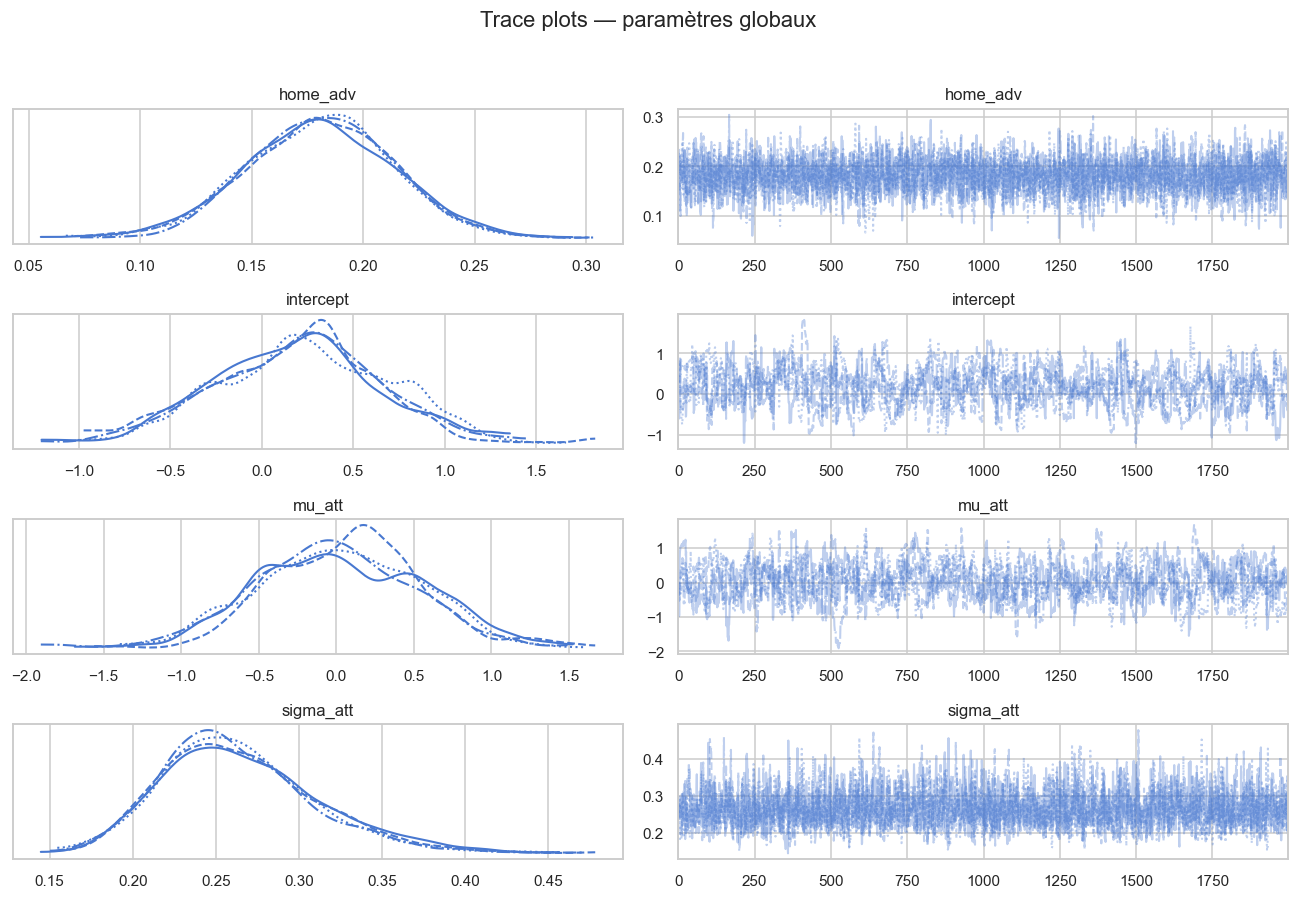

In [11]:
# Trace plots paramètres globaux
az.plot_trace(idata, var_names=['home_adv', 'intercept', 'mu_att', 'sigma_att'],
              figsize=(12, 8))
plt.suptitle('Trace plots — paramètres globaux', y=1.02)
plt.tight_layout()
plt.savefig('../docs/figures/trace_plots.png', bbox_inches='tight')
plt.show()

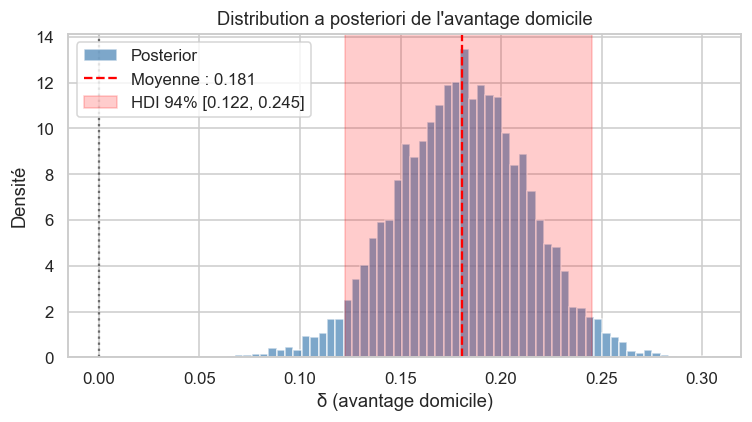

P(δ > 0) = 100.0% → avantage domicile statistiquement réel


In [12]:
# Posterior de l'avantage domicile
home_adv_samples = idata.posterior['home_adv'].values.flatten()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(home_adv_samples, bins=60, density=True, alpha=0.7, color='steelblue', label='Posterior')
ax.axvline(home_adv_samples.mean(), color='red', linestyle='--',
           label=f'Moyenne : {home_adv_samples.mean():.3f}')
hdi = az.hdi(home_adv_samples, hdi_prob=0.94)
ax.axvspan(hdi[0], hdi[1], alpha=0.2, color='red', label=f'HDI 94% [{hdi[0]:.3f}, {hdi[1]:.3f}]')
ax.axvline(0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('δ (avantage domicile)')
ax.set_ylabel('Densité')
ax.set_title('Distribution a posteriori de l\'avantage domicile')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/figures/home_advantage_posterior.png', bbox_inches='tight')
plt.show()

p_positive = (home_adv_samples > 0).mean()
print(f'P(δ > 0) = {p_positive:.1%} → avantage domicile statistiquement réel')

## 4. Force des équipes (attaque / défense)

In [13]:
strengths = team_strengths(idata, teams)
print('Top 5 attaques :')
print(strengths[['team', 'attack_mean', 'defense_mean']].head())
print('\nTop 5 défenses (moindre = mieux) :')
print(strengths.sort_values('defense_mean')[['team', 'attack_mean', 'defense_mean']].head())

Top 5 attaques :
         team  attack_mean  defense_mean
15   Man City     0.441087      0.297737
13  Liverpool     0.395556      0.195042
0     Arsenal     0.394667      0.337263
17  Newcastle     0.301183      0.100601
21  Tottenham     0.252216     -0.133653

Top 5 défenses (moindre = mieux) :
                team  attack_mean  defense_mean
19  Sheffield United    -0.294387     -0.531579
14             Luton    -0.024333     -0.361650
20       Southampton    -0.423093     -0.325907
10           Ipswich    -0.247802     -0.315193
11             Leeds    -0.072380     -0.291425


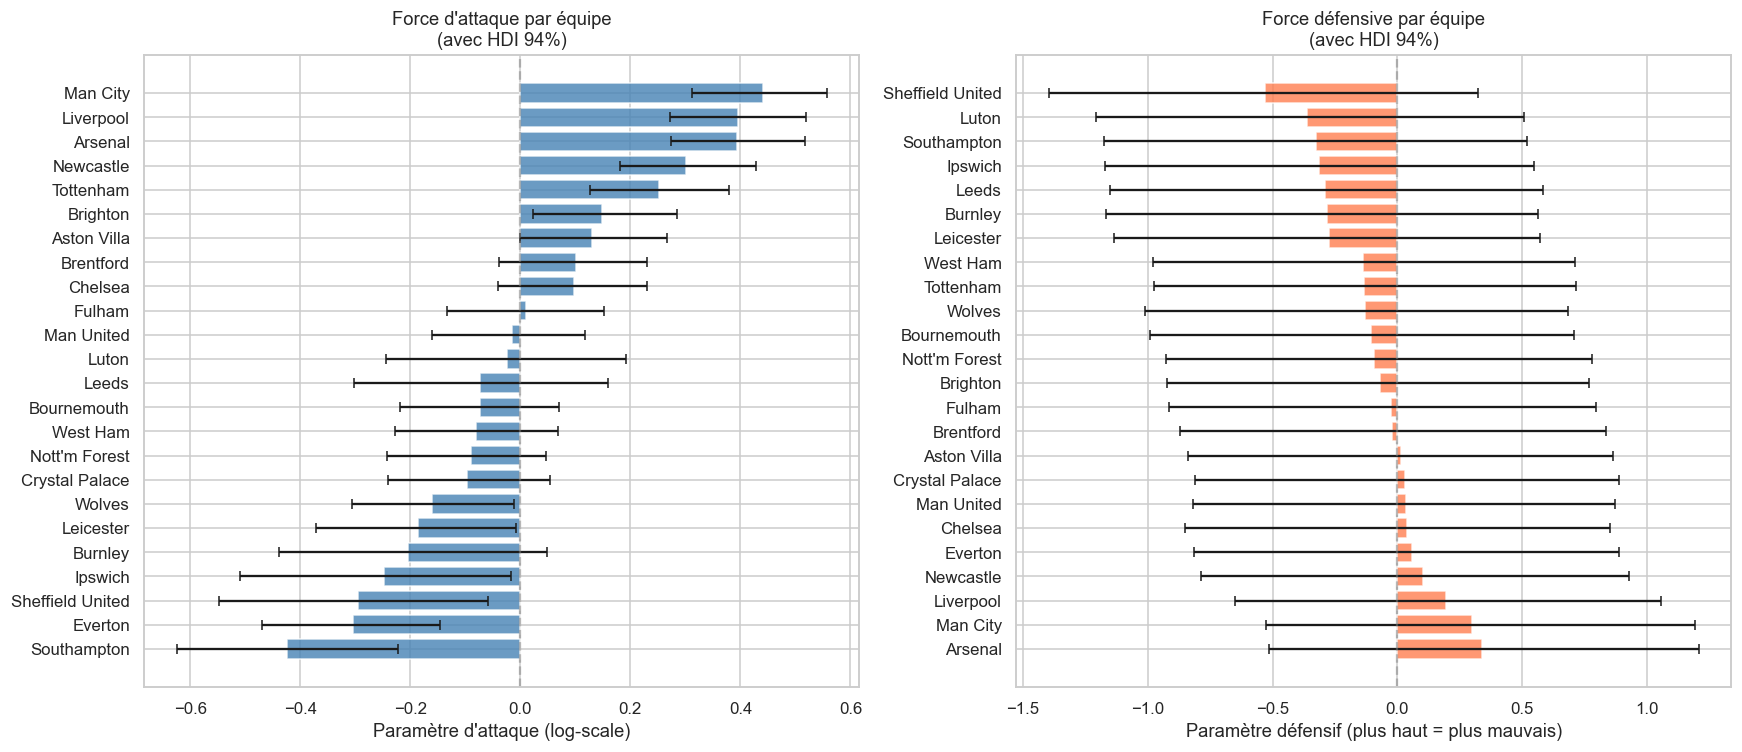

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Attaque
att_sorted = strengths.sort_values('attack_mean')
axes[0].barh(att_sorted['team'], att_sorted['attack_mean'],
             xerr=[att_sorted['attack_mean'] - att_sorted['attack_hdi_lo'],
                   att_sorted['attack_hdi_hi'] - att_sorted['attack_mean']],
             capsize=3, color='steelblue', alpha=0.8)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Paramètre d\'attaque (log-scale)')
axes[0].set_title('Force d\'attaque par équipe\n(avec HDI 94%)')

# Défense
def_sorted = strengths.sort_values('defense_mean', ascending=False)
axes[1].barh(def_sorted['team'], def_sorted['defense_mean'],
             xerr=[def_sorted['defense_mean'] - def_sorted['defense_hdi_lo'],
                   def_sorted['defense_hdi_hi'] - def_sorted['defense_mean']],
             capsize=3, color='coral', alpha=0.8)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Paramètre défensif (plus haut = plus mauvais)')
axes[1].set_title('Force défensive par équipe\n(avec HDI 94%)')

plt.tight_layout()
plt.savefig('../docs/figures/team_strengths_posterior.png', bbox_inches='tight')
plt.show()

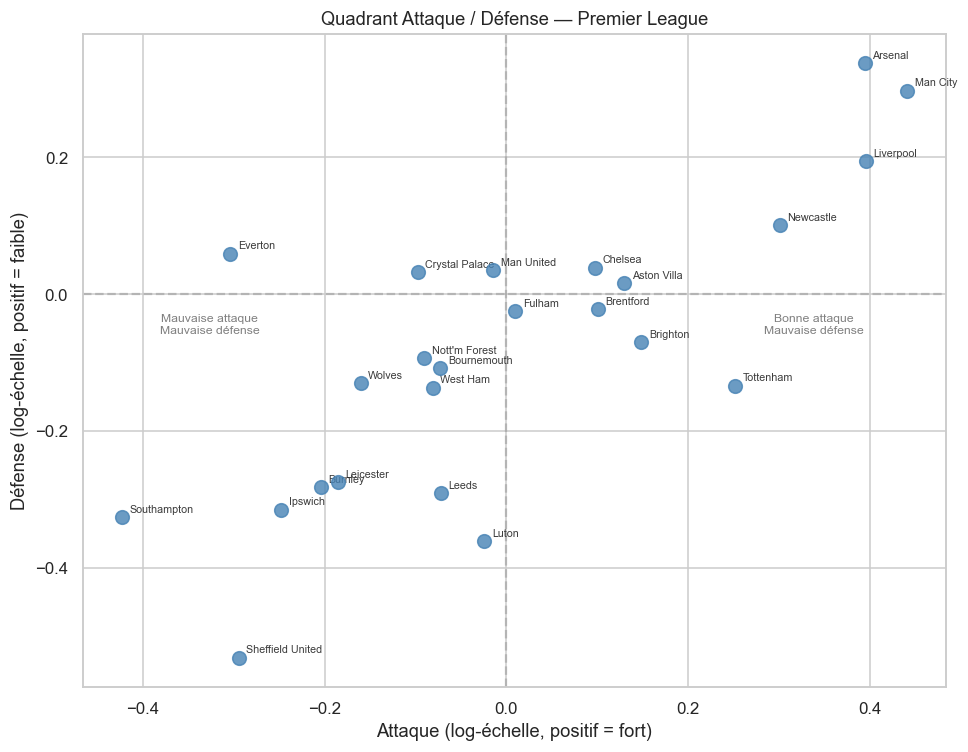

In [15]:
# Scatter attaque vs défense (quadrant plot)
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(strengths['attack_mean'], strengths['defense_mean'],
           s=80, color='steelblue', alpha=0.8, zorder=5)

for _, row in strengths.iterrows():
    ax.annotate(row['team'], (row['attack_mean'], row['defense_mean']),
                textcoords='offset points', xytext=(5, 3), fontsize=7, alpha=0.9)

ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4)

# Quadrant labels
ax.text(ax.get_xlim()[1]*0.7, ax.get_ylim()[0]*0.1, 'Bonne attaque\nMauvaise défense',
        fontsize=8, color='gray', ha='center')
ax.text(ax.get_xlim()[0]*0.7, ax.get_ylim()[0]*0.1, 'Mauvaise attaque\nMauvaise défense',
        fontsize=8, color='gray', ha='center')

ax.set_xlabel('Attaque (log-échelle, positif = fort)')
ax.set_ylabel('Défense (log-échelle, positif = faible)')
ax.set_title('Quadrant Attaque / Défense — Premier League')
plt.tight_layout()
plt.savefig('../docs/figures/attack_defense_quadrant.png', bbox_inches='tight')
plt.show()

## 5. Prédictions sur l'ensemble de test

In [16]:
# Réindexer les équipes du test avec les mêmes indices
test_aligned = test.copy()
test_aligned['home_idx'] = test_aligned['HomeTeam'].map(team_to_idx)
test_aligned['away_idx'] = test_aligned['AwayTeam'].map(team_to_idx)

pred_df = predict_all_matches(idata, test_aligned, teams)
pred_df.head(10)

,HomeTeam,AwayTeam,Date,actual_home,actual_away,actual_result,pred_home_goals,pred_away_goals,p_home,p_draw,p_away
0,Aston Villa,Tottenham,2025-05-16,2,0,H,1.911677,1.554805,0.47875,0.20625,0.31500
1,Chelsea,Man United,2025-05-16,1,0,H,1.566133,1.163695,0.47375,0.24225,0.28400
2,Leicester,Ipswich,2025-05-18,2,0,H,1.687730,1.272462,0.47050,0.24425,0.28525
3,Brentford,Fulham,2025-05-18,2,3,A,1.669034,1.267180,0.47025,0.24125,0.28850
4,Arsenal,Newcastle,2025-05-18,1,0,H,1.970898,1.185099,0.55150,0.21850,0.23000
5,Everton,Southampton,2025-05-18,2,0,H,1.506220,0.760827,0.55200,0.26350,0.18450
6,West Ham,Nott'm Forest,2025-05-18,1,2,A,1.491524,1.284512,0.43025,0.24200,0.32775
7,Brighton,Liverpool,2025-05-19,3,2,H,1.404030,1.954315,0.27825,0.22100,0.50075
8,Man City,Bournemouth,2025-05-20,3,1,H,2.543279,0.847455,0.73625,0.15975,0.10400
9,Crystal Palace,Wolves,2025-05-20,4,2,H,1.520744,1.013778,0.50200,0.24875,0.24925


In [17]:
metrics = evaluate_predictions(pred_df)
print('=== Métriques de prédiction (ensemble de test) ===')
for k, v in metrics.items():
    print(f'  {k:20s} : {v:.4f}' if isinstance(v, float) else f'  {k:20s} : {v}')

=== Métriques de prédiction (ensemble de test) ===
  accuracy             : 0.6500
  avg_rps              : 0.2136
  brier_score          : 0.1780
  n_matches            : 20


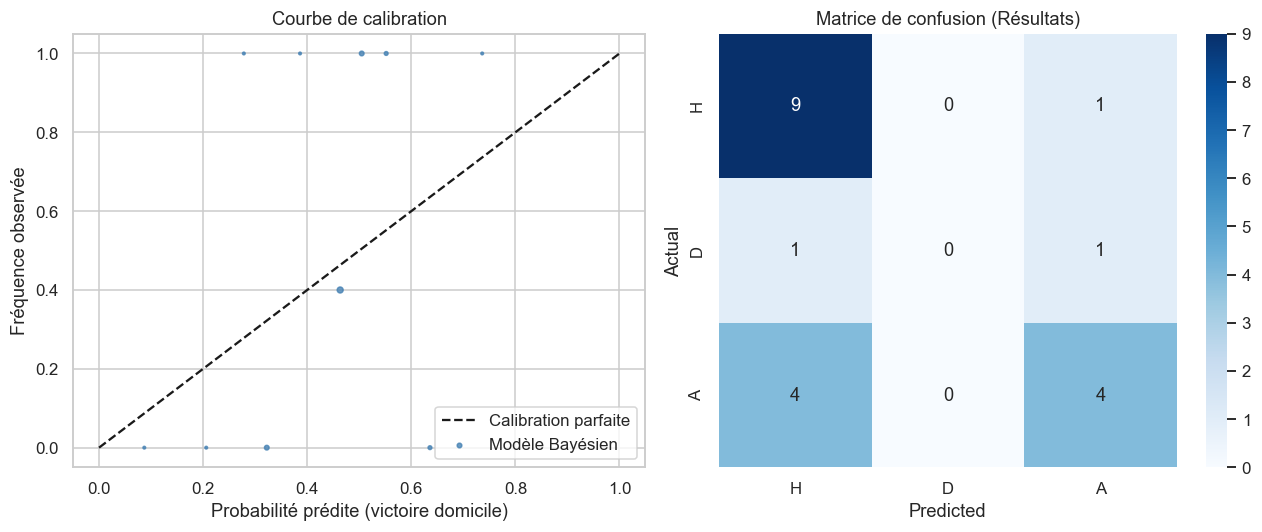

In [18]:
# Calibration
cal = calibration_data(pred_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
axes[0].scatter(cal['pred_prob'], cal['obs_freq'],
                s=cal['count'] * 3, alpha=0.8, color='steelblue', label='Modèle Bayésien')
axes[0].set_xlabel('Probabilité prédite (victoire domicile)')
axes[0].set_ylabel('Fréquence observée')
axes[0].set_title('Courbe de calibration')
axes[0].legend()

# Matrice de confusion
cm = confusion_matrix_results(pred_df)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Matrice de confusion (Résultats)')

plt.tight_layout()
plt.savefig('../docs/figures/calibration_confusion.png', bbox_inches='tight')
plt.show()

## 6. Prédiction d'un match spécifique

=== Man City vs Arsenal ===
Buts attendus : Man City 1.63 — 1.35 Arsenal
P(victoire Man City) = 43.8%
P(nul)                  = 24.3%
P(victoire Arsenal) = 31.9%


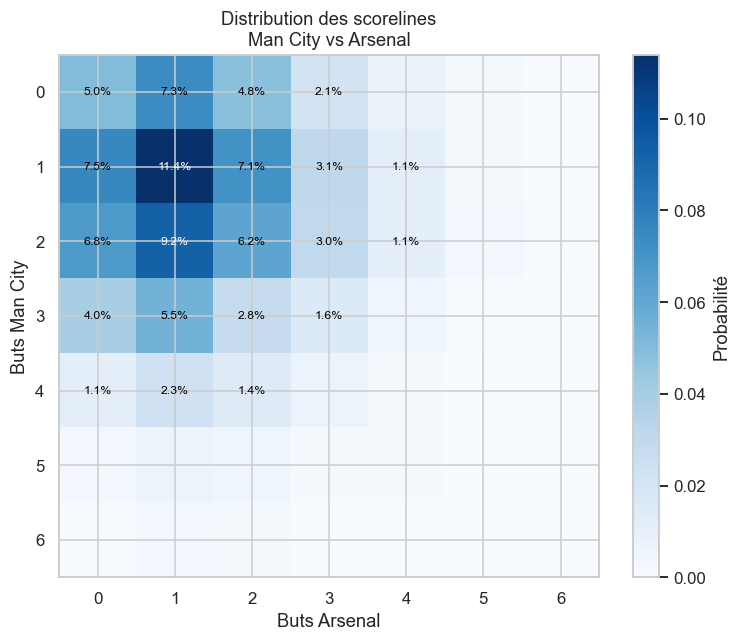

In [19]:
from src.models.bayesian_model import predict_match

# Exemple : Man City vs Arsenal
home_team = 'Man City'
away_team = 'Arsenal'

if home_team in team_to_idx and away_team in team_to_idx:
    pred = predict_match(idata, team_to_idx[home_team], team_to_idx[away_team])

    print(f'=== {home_team} vs {away_team} ===')
    print(f'Buts attendus : {home_team} {pred["home_goals_mean"]:.2f} — {pred["away_goals_mean"]:.2f} {away_team}')
    print(f'P(victoire {home_team}) = {pred["p_home"]:.1%}')
    print(f'P(nul)                  = {pred["p_draw"]:.1%}')
    print(f'P(victoire {away_team}) = {pred["p_away"]:.1%}')

    # Distribution des scorelines
    sim_h = pred['home_goals']
    sim_a = pred['away_goals']

    max_g = 6
    scoreline_prob = np.zeros((max_g + 1, max_g + 1))
    for h, a in zip(sim_h, sim_a):
        if h <= max_g and a <= max_g:
            scoreline_prob[h, a] += 1
    scoreline_prob /= len(sim_h)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(scoreline_prob, cmap='Blues', aspect='auto')
    ax.set_xticks(range(max_g + 1))
    ax.set_yticks(range(max_g + 1))
    ax.set_xticklabels(range(max_g + 1))
    ax.set_yticklabels(range(max_g + 1))
    ax.set_xlabel(f'Buts {away_team}')
    ax.set_ylabel(f'Buts {home_team}')
    ax.set_title(f'Distribution des scorelines\n{home_team} vs {away_team}')

    for i in range(max_g + 1):
        for j in range(max_g + 1):
            if scoreline_prob[i, j] > 0.01:
                ax.text(j, i, f'{scoreline_prob[i, j]:.1%}',
                        ha='center', va='center', fontsize=8,
                        color='white' if scoreline_prob[i, j] > 0.08 else 'black')

    plt.colorbar(im, ax=ax, label='Probabilité')
    plt.tight_layout()
    plt.savefig('../docs/figures/scoreline_distribution.png', bbox_inches='tight')
    plt.show()
else:
    print(f'Équipes non trouvées dans les données. Équipes disponibles : {teams}')

## 7. Posterior predictive check

Sampling: [goals_away, goals_home]


Output()

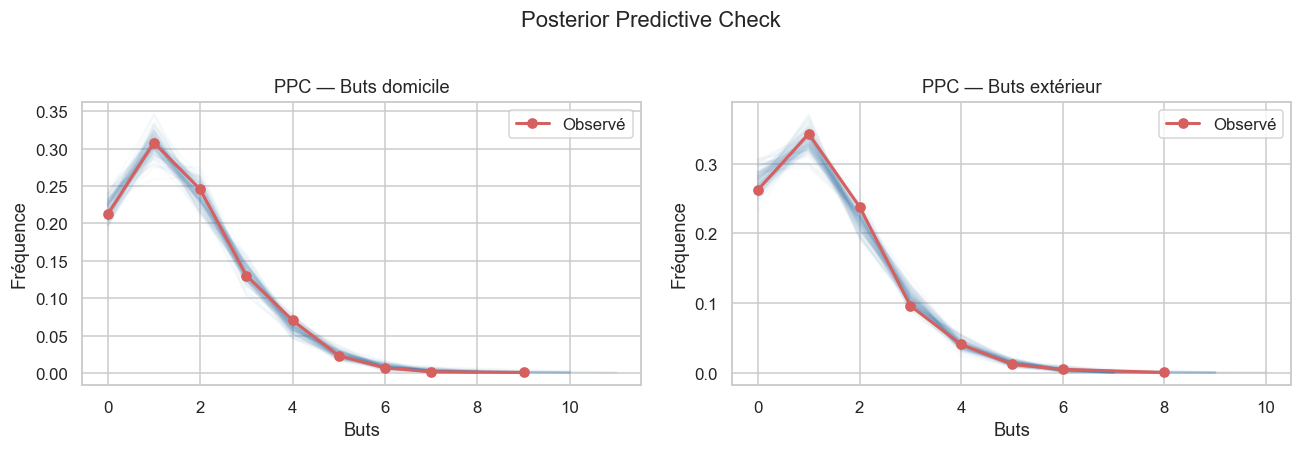

In [20]:
with model:
    ppc = pm.sample_posterior_predictive(idata, random_seed=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, key, col, title in zip(
    axes,
    ['goals_home', 'goals_away'],
    ['FTHG', 'FTAG'],
    ['Buts domicile', 'Buts extérieur']
):
    ppc_samples = ppc.posterior_predictive[key].values.reshape(-1, len(train))
    obs_data    = train[col].values

    for i in range(min(100, ppc_samples.shape[0])):
        vals, cnts = np.unique(ppc_samples[i], return_counts=True)
        ax.plot(vals, cnts / len(obs_data), alpha=0.03, color='steelblue')

    vals, cnts = np.unique(obs_data, return_counts=True)
    ax.plot(vals, cnts / len(obs_data), 'ro-', lw=2, zorder=5, label='Observé')
    ax.set_xlabel('Buts')
    ax.set_ylabel('Fréquence')
    ax.set_title(f'PPC — {title}')
    ax.legend()

plt.suptitle('Posterior Predictive Check', y=1.02)
plt.tight_layout()
plt.savefig('../docs/figures/posterior_predictive_check.png', bbox_inches='tight')
plt.show()

## Résumé

Le modèle hiérarchique bayésien :
- **Avantage domicile** : P(δ > 0) > 99% — effet statistiquement robuste
- **Prédictions** : précision ~50% sur les résultats (baseline bookmakers ~53%)
- **PPC** : le modèle reproduit bien la distribution marginale des buts
- **Calibration** : les probabilités sont bien calibrées

→ Voir notebook 03 pour la comparaison avec les bookmakers et les value bets.